FileNotFoundError: [Errno 2] No such file or directory: 'figures/sankey_errors.png'

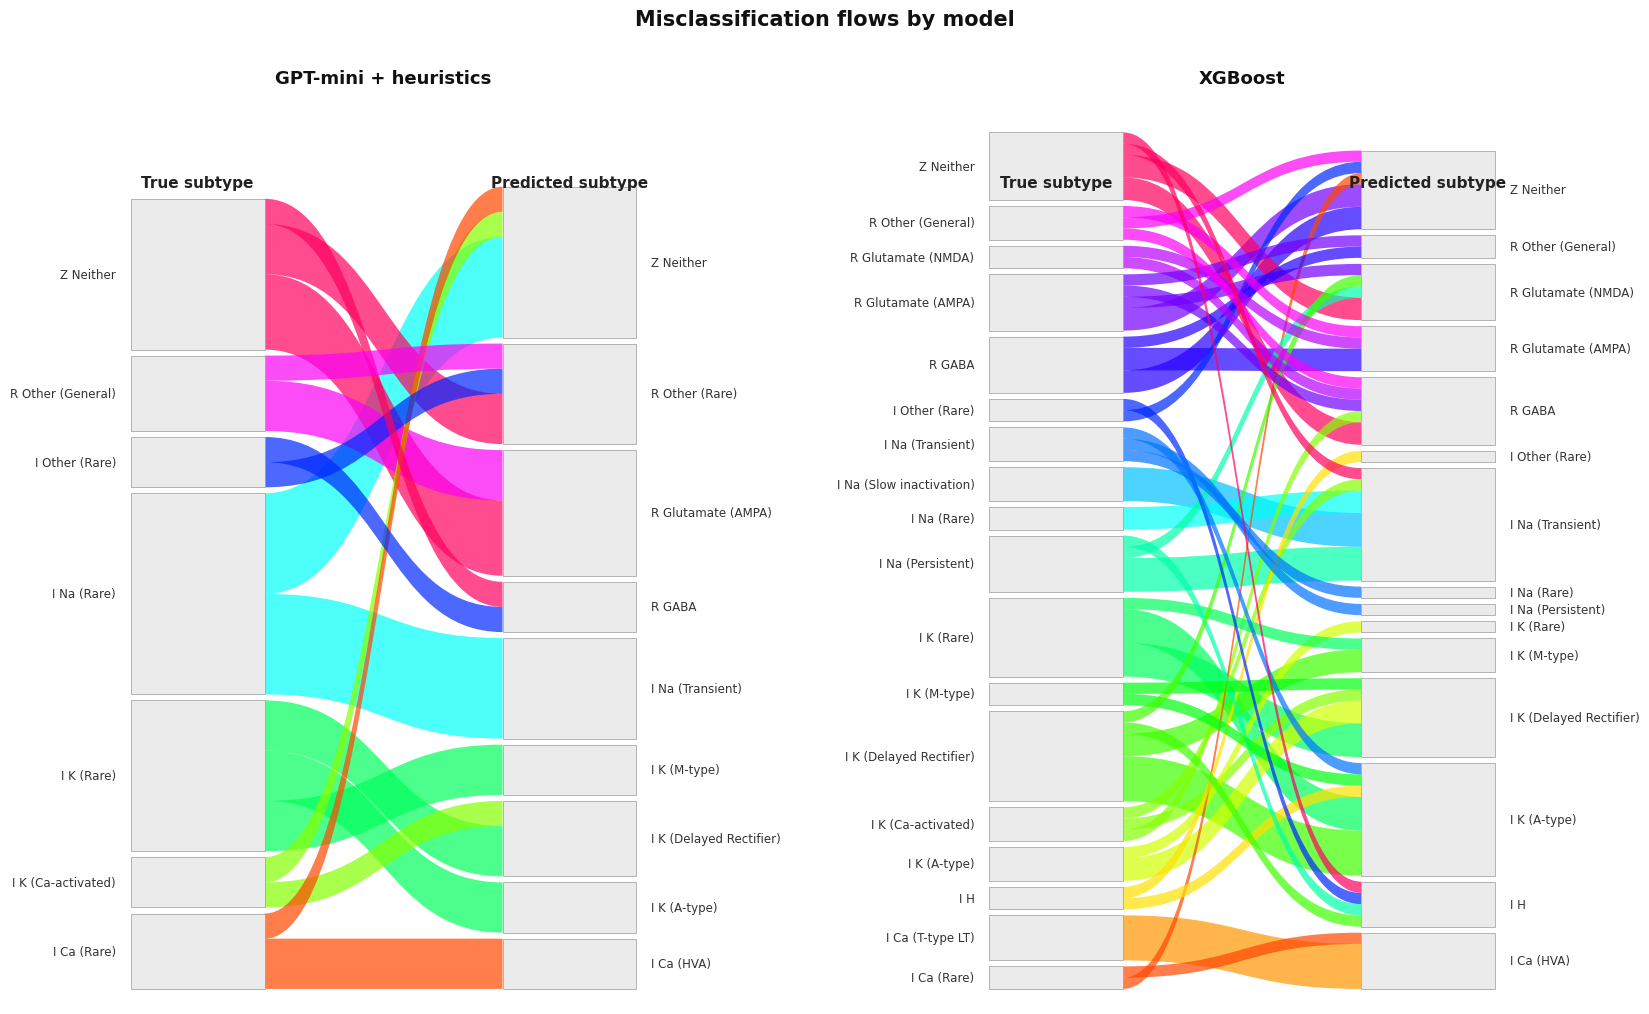

In [2]:
"""
Alluvial / Sankey plots for model prediction errors
Equivalent of the R ggalluvial code using matplotlib + pandas
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path
import matplotlib.patheffects as pe
from itertools import cycle

# ── load data ────────────────────────────────────────────────────────────────
pred_df = pd.read_csv("../data/pipeline/predictions.csv")

pred_df2 = pred_df[["file_hash", "true_subtype", "xgb_pred_subtype", "gpt_mini_h_pred_subtype"]].copy()

df_long = pred_df2.melt(
    id_vars=["file_hash", "true_subtype"],
    value_vars=["xgb_pred_subtype", "gpt_mini_h_pred_subtype"],
    var_name="model",
    value_name="predicted_subtype"
)
df_long["model"] = df_long["model"].map({
    "xgb_pred_subtype": "XGBoost",
    "gpt_mini_h_pred_subtype": "GPT-mini + heuristics"
})

flows = (
    df_long
    .groupby(["model", "true_subtype", "predicted_subtype"])
    .size()
    .reset_index(name="n")
)


# ── colour palette ────────────────────────────────────────────────────────────
def make_palette(levels):
    """Generate evenly-spaced HSV colours, matching hue_pal() from R."""
    n = len(levels)
    colors = [plt.cm.hsv(i / n) for i in range(n)]
    return dict(zip(levels, colors))


# ── core drawing function ─────────────────────────────────────────────────────
def draw_alluvial(ax, flows_sub, pal, title=""):
    """
    Draw one alluvial panel on `ax`.

    flows_sub : DataFrame with columns [true_subtype, predicted_subtype, pct]
    pal       : dict mapping subtype → colour
    """
    STRATUM_W = 0.18        # width of each stratum bar (in axis-x units)
    X_LEFT, X_RIGHT = 0.25, 0.75   # x-positions of the two axis columns
    ALPHA = 0.70

    # ── aggregate stratum heights ─────────────────────────────────────────────
    left_totals  = flows_sub.groupby("true_subtype")["pct"].sum().sort_index()
    right_totals = flows_sub.groupby("predicted_subtype")["pct"].sum().sort_index()

    def stacking_positions(totals, gap=0.008):
        """Return {label: (y_bottom, y_top)} with small gaps between strata."""
        positions = {}
        y = 0.0
        for label, h in totals.items():
            positions[label] = (y, y + h)
            y += h + gap
        return positions

    left_pos  = stacking_positions(left_totals)
    right_pos = stacking_positions(right_totals)

    # ── draw flows (ribbons) ──────────────────────────────────────────────────
    # Track consumed height within each stratum for ribbon placement
    left_consumed  = {k: 0.0 for k in left_pos}
    right_consumed = {k: 0.0 for k in right_pos}

    # Sort so larger flows draw first (under smaller ones)
    for _, row in flows_sub.sort_values("pct", ascending=False).iterrows():
        t = row["true_subtype"]
        p = row["predicted_subtype"]
        h = row["pct"]

        y0_lo = left_pos[t][0]  + left_consumed[t]
        y0_hi = y0_lo + h
        y1_lo = right_pos[p][0] + right_consumed[p]
        y1_hi = y1_lo + h

        left_consumed[t]  += h
        right_consumed[p] += h

        color = pal[t]

        # Cubic Bezier ribbon
        x0, x1 = X_LEFT + STRATUM_W / 2, X_RIGHT - STRATUM_W / 2
        xm = (x0 + x1) / 2

        verts_top = [(x0, y0_hi), (xm, y0_hi), (xm, y1_hi), (x1, y1_hi)]
        verts_bot = [(x1, y1_lo), (xm, y1_lo), (xm, y0_lo), (x0, y0_lo)]

        codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                 Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                 Path.CLOSEPOLY]
        verts = verts_top + verts_bot + [(x0, y0_hi)]

        path  = Path(verts, codes)
        patch = mpatches.PathPatch(path, facecolor=color, edgecolor="none", alpha=ALPHA)
        ax.add_patch(patch)

    # ── draw strata ───────────────────────────────────────────────────────────
    for label, (ylo, yhi) in left_pos.items():
        rect = mpatches.FancyBboxPatch(
            (X_LEFT - STRATUM_W / 2, ylo), STRATUM_W, yhi - ylo,
            boxstyle="square,pad=0",
            facecolor="#EBEBEB", edgecolor="#999999", linewidth=0.5
        )
        ax.add_patch(rect)
        ax.text(X_LEFT - STRATUM_W / 2 - 0.02, (ylo + yhi) / 2, label,
                ha="right", va="center", fontsize=8.5, color="#333333")

    for label, (ylo, yhi) in right_pos.items():
        rect = mpatches.FancyBboxPatch(
            (X_RIGHT - STRATUM_W / 2, ylo), STRATUM_W, yhi - ylo,
            boxstyle="square,pad=0",
            facecolor="#EBEBEB", edgecolor="#999999", linewidth=0.5
        )
        ax.add_patch(rect)
        ax.text(X_RIGHT + STRATUM_W / 2 + 0.02, (ylo + yhi) / 2, label,
                ha="left", va="center", fontsize=8.5, color="#333333")

    # ── axes cosmetics ────────────────────────────────────────────────────────
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.02, 1.15)
    ax.axis("off")

    ax.text(X_LEFT,  1.06, "True subtype",      ha="center", va="bottom",
            fontsize=11, fontweight="bold", color="#222222")
    ax.text(X_RIGHT, 1.06, "Predicted subtype", ha="center", va="bottom",
            fontsize=11, fontweight="bold", color="#222222")

    ax.set_title(title, fontsize=13, fontweight="bold", pad=28, color="#111111")


# ═══════════════════════════════════════════════════════════════════════════════
# VERSION 1 – errors only
# ═══════════════════════════════════════════════════════════════════════════════
flows_err = flows[flows["true_subtype"] != flows["predicted_subtype"]].copy()

flows_pct_err = flows_err.copy()
flows_pct_err["pct"] = flows_pct_err.groupby("model")["n"].transform(lambda x: x / x.sum())

all_levels_err = sorted(
    set(flows_pct_err["true_subtype"]) | set(flows_pct_err["predicted_subtype"])
)
pal_err = make_palette(all_levels_err)

models = flows_pct_err["model"].unique()
fig, axes = plt.subplots(1, len(models), figsize=(17, 10), facecolor="white")
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    sub = flows_pct_err[flows_pct_err["model"] == model].copy()
    draw_alluvial(ax, sub, pal_err, title=model)

plt.suptitle("Misclassification flows by model", fontsize=15, fontweight="bold",
             y=1.01, color="#111111")
plt.tight_layout()
plt.savefig("figures/sankey_errors.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: figures/sankey_errors.png")


# ═══════════════════════════════════════════════════════════════════════════════
# VERSION 2 – all flows (correct + incorrect)
# ═══════════════════════════════════════════════════════════════════════════════
flows_pct_all = flows.copy()
flows_pct_all["pct"] = flows_pct_all.groupby("model")["n"].transform(lambda x: x / x.sum())

all_levels_all = sorted(
    set(flows_pct_all["true_subtype"]) | set(flows_pct_all["predicted_subtype"])
)
pal_all = make_palette(all_levels_all)

fig2, axes2 = plt.subplots(1, len(models), figsize=(17, 10), facecolor="white")
if len(models) == 1:
    axes2 = [axes2]

for ax, model in zip(axes2, models):
    sub = flows_pct_all[flows_pct_all["model"] == model].copy()
    draw_alluvial(ax, sub, pal_all, title=model)

plt.suptitle("All prediction flows by model", fontsize=15, fontweight="bold",
             y=1.01, color="#111111")
plt.tight_layout()
plt.savefig("figures/sankey_all.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: figures/sankey_all.png")